Decision Tree

In [47]:
import json
import pandas as pd
import numpy as np
import re
import nltk
from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn.metrics import classification_report
from textblob import TextBlob
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from matplotlib import pyplot as plt

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [48]:
file_path = '/content/combined_df.json'

fixed_lines = []
with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        try:
            fixed_lines.append(json.loads(line.strip()))
        except json.JSONDecodeError:
            continue
df = pd.DataFrame(fixed_lines)
df = df.dropna(subset=['review_text', 'plot_summary', 'is_spoiler'])
df.tail()

,review_date,movie_id,user_id,is_spoiler,review_text,rating_x,review_summary,plot_summary,duration,genre,rating_y,release_date,plot_synopsis
36352,6 July 2015,tt2582802,ur38432904,True,"With nearly no soundtrack, Whiplash still mana...",10,Whiplash hit a high note,A young and talented drummer attending a prest...,1h 47min,"[Drama, Music]",8.5,2014-10-15,The films opens with Andrew Neimann (Miles Tel...
36353,4 July 2015,tt2582802,ur22563365,True,Thank goodness the makers of this film denounc...,10,Performance art: where virtue and vice trade p...,A young and talented drummer attending a prest...,1h 47min,"[Drama, Music]",8.5,2014-10-15,The films opens with Andrew Neimann (Miles Tel...
36354,3 July 2015,tt2582802,ur39866228,True,Aside from the abusive teaching style (which I...,9,Possible Spoiler: Acceptable of difference in ...,A young and talented drummer attending a prest...,1h 47min,"[Drama, Music]",8.5,2014-10-15,The films opens with Andrew Neimann (Miles Tel...
36355,23 June 2015,tt2582802,ur60535218,True,"Being a musician for the past 10 or so years, ...",9,Near Perfection,A young and talented drummer attending a prest...,1h 47min,"[Drama, Music]",8.5,2014-10-15,The films opens with Andrew Neimann (Miles Tel...
36356,8 June 2015,tt2582802,ur30794704,True,When I seen the trailers for this I wasn't ver...,9,"""Witty music related remark""",A young and talented drummer attending a prest...,1h 47min,"[Drama, Music]",8.5,2014-10-15,The films opens with Andrew Neimann (Miles Tel...


Adaptation of Liad's homework

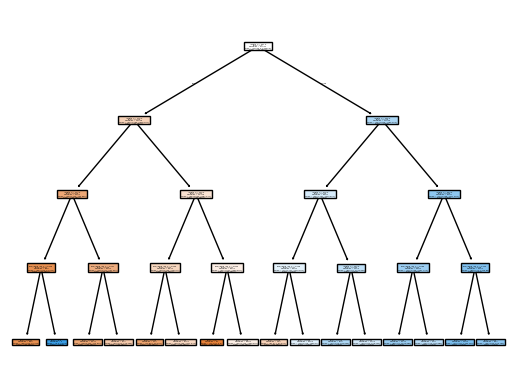

              precision    recall  f1-score   support

 non-spoiler       0.84      0.67      0.74      6927
     spoiler       0.36      0.59      0.44      2163

    accuracy                           0.65      9090
   macro avg       0.60      0.63      0.59      9090
weighted avg       0.72      0.65      0.67      9090



'Source.gv.pdf'

In [58]:
label2idx = {False: 0, True: 1}
idx2label = {0: 'non-spoiler', 1: 'spoiler'}

df['full_text'] = df['review_text'] + " " + df['plot_summary']
#labeling
X = df['full_text'].tolist()
y = [label2idx[label] for label in df['is_spoiler']]

#splitting the set
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=True, random_state=1234, stratify=y)

lemmatizer = WordNetLemmatizer()

spoiler_keywords = {
    "spoiler", "dies", "death", "dead", "kill", "killed", "murder", "murderer",
    "killer", "shoot", "shot", "stab", "poison", "betray", "betrayal", "affair",
    "cheat", "affair", "divorce", "suicide", "arrest", "guilty", "innocent",
    "confess", "confession", "reveal", "reveals", "revealed", "identity", "secret",
    "twist", "plot twist", "surprise", "ending", "finale", "escape", "prison",
    "investigation", "detective", "culprit", "accused", "testimony", "verdict",
    "trial", "court", "sentence", "killer", "revenge", "justice", "truth",
    "who", "turns out", "turns", "real", "was actually", "was the"
}

def spoiler_feature_function(review: str) -> list[float]:
    tokens = nltk.word_tokenize(review.lower())
    lemmas = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha()]
    review_length = len(lemmas)
    avg_word_length = np.mean([len(w) for w in lemmas]) if lemmas else 0
    keyword_presence = int(any(word in spoiler_keywords for word in lemmas))
    return [review_length, avg_word_length, keyword_presence]

# Apply feature function
X_train = list(map(spoiler_feature_function, X_train))
X_test = list(map(spoiler_feature_function, X_test))

# Convert to numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)

# Train decision tree
clf = tree.DecisionTreeClassifier(max_depth=4, random_state=1234, class_weight='balanced')
clf = clf.fit(X_train, y_train)

# Visualize tree
tree.plot_tree(clf, feature_names=["length", "avg_word_len", "has_keyword"], class_names=["non-spoiler", "spoiler"], filled=True)
plt.show()

# Evaluation
predictions = clf.predict(X_test)
print(classification_report(y_test, predictions, target_names=["non-spoiler", "spoiler"]))

def predict_spoiler(text: str) -> str:
    features = spoiler_feature_function(text)
    prediction = clf.predict([features])[0]
    return idx2label[prediction]

# Export with graphviz
import graphviz
dot_data = tree.export_graphviz(clf,
                                out_file=None,
                                feature_names=["length", "avg_word_len", "has_keyword"], # Corrected feature_names
                                class_names=["non-spoiler", "spoiler"],
                                filled=True,
                                rounded=True)
graph = graphviz.Source(dot_data)
graph.view()

In [59]:
test_text ="This movie had a great twist at the end when the villain turned out to be his brother."
predict_spoiler(test_text)

'non-spoiler'

Adapted to limit the dataset only to "crime" and "drama"

In [60]:
import re
import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

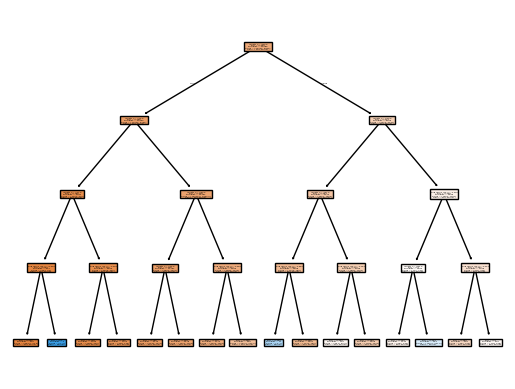

              precision    recall  f1-score   support

 non-spoiler       0.76      0.99      0.86      6927
     spoiler       0.47      0.02      0.03      2163

    accuracy                           0.76      9090
   macro avg       0.62      0.51      0.45      9090
weighted avg       0.69      0.76      0.67      9090



'Source.gv.pdf'

In [61]:

def crime_or_drama(genres):
  return isinstance(genres, list) and any(g.lower() in['crime', 'drama'] for g in genres)
df_filtered = df[df['genre'].apply(crime_or_drama)].dropna(subset=['review_text', 'is_spoiler'])

#df_filtered = df[df['genre'].str.contains('crime', case=False, na=False)]

label2idx = {False: 0, True: 1}
idx2label = {0: 'non-spoiler', 1: 'spoiler'}
#labeling
X_two = (df_filtered['review_text'] + " " + df_filtered['plot_summary']).tolist()
y_two = [label2idx[label] for label in df_filtered['is_spoiler']]

#splitting the set
X_two_train, X_two_test, y_two_train, y_two_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1234, stratify=y)

lemmatizer = WordNetLemmatizer()

spoiler_keywords = {
    "spoiler", "dies", "death", "dead", "kill", "killed", "murder", "murderer",
    "killer", "shoot", "shot", "stab", "poison", "betray", "betrayal", "affair",
    "cheat", "affair", "divorce", "suicide", "arrest", "guilty", "innocent",
    "confess", "confession", "reveal", "reveals", "revealed", "identity", "secret",
    "twist", "plot twist", "surprise", "ending", "finale", "escape", "prison",
    "investigation", "detective", "culprit", "accused", "testimony", "verdict",
    "trial", "court", "sentence", "killer", "revenge", "justice", "truth",
    "who", "turns out", "turns", "real", "was actually", "was the"
}

#def spoiler_feature_function(review: str) -> list[float]:
#    words = re.findall(r'\b\w+\b', review.lower())
#    review_length = len(words)
#    avg_word_length = np.mean([len(w) for w in words] if words else 0)
#    keyword_presence = any(word in spoiler_keywords for word in words)
#    return [review_length, avg_word_length, int(keyword_presence)]

def spoiler_feature_function(text: str) -> list[float]:
    tokens = nltk.word_tokenize(text.lower())
    lemmas = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha()]
    review_length = len(lemmas)
    avg_word_length = np.mean([len(w) for w in lemmas]) if lemmas else 0
    keyword_presence = int(any(word in spoiler_keywords for word in lemmas))
    return [review_length, avg_word_length, keyword_presence]

# Apply feature function
X_two_train = np.array(list(map(spoiler_feature_function, X_two_train)))
X_two_test = np.array(list(map(spoiler_feature_function, X_two_test)))

# Convert to numpy arrays
#X_train = np.array(X_train)
#X_test = np.array(X_test)

# Train decision tree
clf = tree.DecisionTreeClassifier(max_depth=4, random_state=1234)
clf = clf.fit(X_two_train, y_two_train)

# Visualize tree
tree.plot_tree(clf, feature_names=["length", "avg_word_len", "has_keyword"], class_names=["non-spoiler", "spoiler"], filled=True)
plt.show()

# Evaluation
predictions = clf.predict(X_test)
print(classification_report(y_test, predictions, target_names=["non-spoiler", "spoiler"]))

def predict_spoiler(text: str) -> str:
    features = spoiler_feature_function(text)
    prediction = clf.predict([features])[0]
    return idx2label[prediction]

# Export with graphviz
import graphviz
dot_data = tree.export_graphviz(clf,
                                out_file=None,
                                feature_names=["length", "avg_word_len", "has_keyword"], # Corrected feature_names
                                class_names=["non-spoiler", "spoiler"],
                                filled=True,
                                rounded=True)
graph = graphviz.Source(dot_data)
graph.view()

In [40]:
test_text ="This movie had a great twist at the end when the villain turned out to be his brother."
predict_spoiler(test_text)

'non-spoiler'

Adapted to only one genre

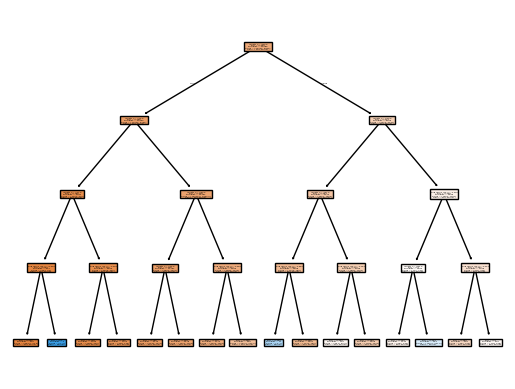

              precision    recall  f1-score   support

 non-spoiler       0.76      0.99      0.86      5542
     spoiler       0.44      0.02      0.03      1730

    accuracy                           0.76      7272
   macro avg       0.60      0.50      0.45      7272
weighted avg       0.69      0.76      0.67      7272



'Source.gv.pdf'

In [57]:

def drama_films(genres):
  return isinstance(genres, list) and any(g.lower() in['drama'] for g in genres)
df_filtered = df[df['genre'].apply(drama_films)].dropna(subset=['review_text', 'is_spoiler'])


label2idx = {False: 0, True: 1}
idx2label = {0: 'non-spoiler', 1: 'spoiler'}
#labeling
X_one = (df_filtered['review_text'] + " " + df_filtered['plot_summary']).tolist()
y_one = [label2idx[label] for label in df_filtered['is_spoiler']]

#splitting the set
X_one_train, X_one_test, y_one_train, y_one_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=1234, stratify=y)

lemmatizer = WordNetLemmatizer()

spoiler_keywords = {
    "spoiler", "dies", "death", "dead", "kill", "killed", "murder", "murderer",
    "killer", "shoot", "shot", "stab", "poison", "betray", "betrayal", "affair",
    "cheat", "affair", "divorce", "suicide", "arrest", "guilty", "innocent",
    "confess", "confession", "reveal", "reveals", "revealed", "identity", "secret",
    "twist", "plot twist", "surprise", "ending", "finale", "escape", "prison",
    "investigation", "detective", "culprit", "accused", "testimony", "verdict",
    "trial", "court", "sentence", "killer", "revenge", "justice", "truth",
    "who", "turns out", "turns", "real", "was actually", "was the"
}



def spoiler_feature_function(text: str) -> list[float]:
    tokens = nltk.word_tokenize(text.lower())
    lemmas = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha()]
    review_length = len(lemmas)
    avg_word_length = np.mean([len(w) for w in lemmas]) if lemmas else 0
    keyword_presence = int(any(word in spoiler_keywords for word in lemmas))
    return [review_length, avg_word_length, keyword_presence]

# Apply feature function
X_one_train = np.array(list(map(spoiler_feature_function, X_one_train)))
X_one_test = np.array(list(map(spoiler_feature_function, X_one_test)))


# Train decision tree
clf = tree.DecisionTreeClassifier(max_depth=4, random_state=1234)
clf = clf.fit(X_one_train, y_one_train)

# Visualize tree
tree.plot_tree(clf, feature_names=["length", "avg_word_len", "has_keyword"], class_names=["non-spoiler", "spoiler"], filled=True)
plt.show()

# Evaluation
predictions = clf.predict(X_test)
print(classification_report(y_test, predictions, target_names=["non-spoiler", "spoiler"]))

def predict_spoiler(text: str) -> str:
    features = spoiler_feature_function(text)
    prediction = clf.predict([features])[0]
    return idx2label[prediction]

# Export with graphviz
import graphviz
dot_data = tree.export_graphviz(clf,
                                out_file=None,
                                feature_names=["length", "avg_word_len", "has_keyword"], # Corrected feature_names
                                class_names=["non-spoiler", "spoiler"],
                                filled=True,
                                rounded=True)
graph = graphviz.Source(dot_data)
graph.view()